***Medical Cost Prediction Project***

***Name:*** Tahniyat Javaid

***Internship Program:*** *DevelopersHub Corporation*

***Project Overview:***

*This project focuses on analyzing the Medical Cost Personal Dataset and building a machine learning model to predict individual medical insurance* *charges based on demographic and health-related features.*

*The objective is to:*

- *Perform data exploration to understand feature distributions and relationships*

- *Visualize the impact of factors like age, BMI, and smoking status on medical charges*

- *Preprocess the data for machine learning modeling*

- *Build and evaluate a regression model to predict insurance costs.*

- *Identify the key factors influencing medical expenses.*

***Import necessary Libraries:***

In [117]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

***Loading the Dataset:***

In [118]:
# 2. Load Dataset

df = pd.read_csv("C:/Users/HC/OneDrive/Documents/Internship 2026/Task 4/insurance.csv")


In [119]:
# Display first 5 rows
print("Display first 5 rows:")
df.head()

Display first 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [120]:
# 3. Convert Text Columns into Numbers

df = pd.get_dummies(df, drop_first=True)

In [121]:
# 4. Define X (inputs) and y (target)

X = df.drop("charges", axis=1)
y = df["charges"]

***Split Dataset:***

In [122]:
# 5. Split Data (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

***Model Training:***

In [123]:
# 6. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


***Model Prediction:***

In [124]:
# 7. Make Predictions
y_pred = model.predict(X_test)

*** Model Evaluation***

*Calculate performance metrics*

In [125]:
# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 4181.19447375365
RMSE: 5796.284659276272


***Visualization:***

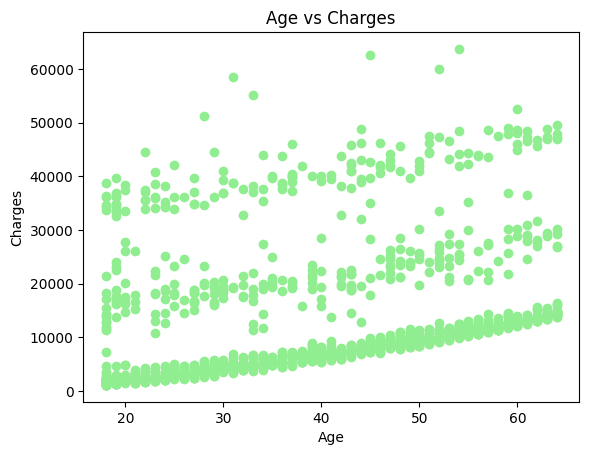

In [126]:
# Age vs Charges
plt.scatter(df["age"], df["charges"], color = 'lightgreen')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

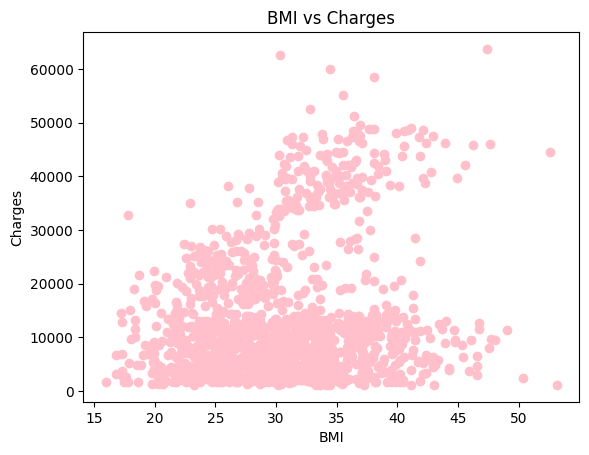

In [127]:
# BMI vs Charges
plt.scatter(df["bmi"], df["charges"], color ='pink')
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges")
plt.show()

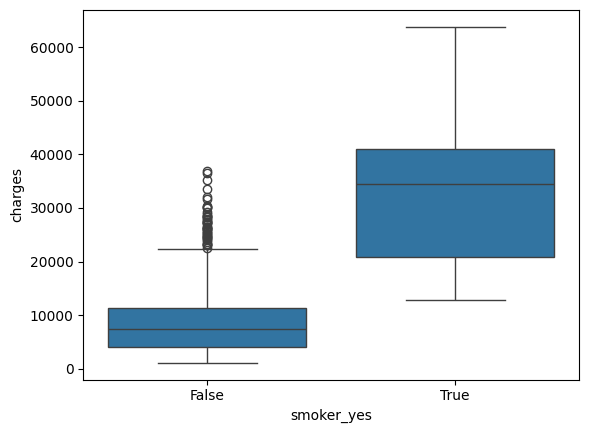

In [128]:
# Smoking vs Charges
sns.boxplot(x="smoker_yes", y="charges", data=df)
plt.show()

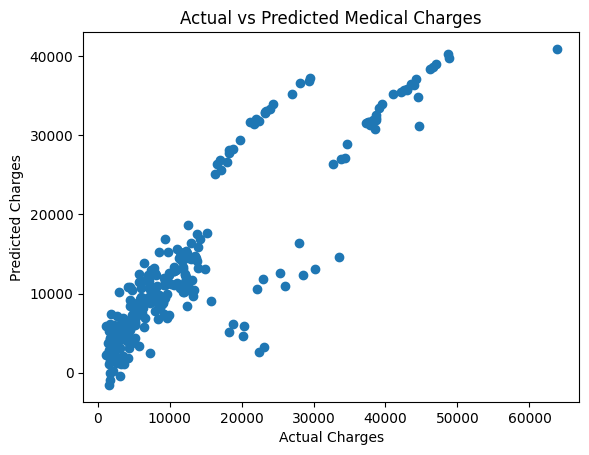

In [129]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Charges")
plt.show()